# Section 5 &middot; Features That Describe the Setup

*The Honest Edge.*

Section 4 gave us the **answer key**: for each of the 168 oversold dips, a meta-label
(1 = take, 0 = skip) and a sample weight. That is the `y` and the weights of a training
set. This section builds the other half, the **`X`**: at each dip, a row of numbers that
*describe the setup* the model will look at before it decides take-or-skip.

A model is only as good as what it can see. If the features do not carry information
about which dips bounce and which keep falling, no amount of modeling in Section 6 will
help. So we build the features carefully, explain the story behind each one, and then,
honestly, ask the uncomfortable question: **do they actually look useful, or not?**

## What makes a feature *honest*

A feature is a number computed at the dip's entry bar `t`, using data **only up to and
including `t`'s close**. That is the no-look-ahead contract again, applied to inputs:

- The **label** is allowed to peek into the future (it is the answer). A **feature**
  never is. Same data, opposite direction in time.
- We use **trailing windows only**: a 21-day average looks back, never around the
  current bar (a centered window would borrow tomorrow). We never normalize a feature
  using the whole history's mean and standard deviation, because that quietly leaks the
  future into the present.
- We are heading for **tree-based** models (Section 6's CatBoost), which split on one
  feature at a time and do not care about a feature's scale. So, unlike a linear model
  or a neural net, we do **not** standardize the inputs. One less knob, one less way to
  leak.

Each feature below is computed once, as a causal series over all of history, in
`honest_edge/features.py`, then read off at the dip dates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from honest_edge import data, signal, labeling as lab, features as ft, evaluation as ev

spy = data.load_spy_daily()
close = spy["close"]

# The same 168 distinct dips, with their Section 4 labels and weights.
entry, _ = signal.connors_rsi2_signals(spy, rsi_buy=10)
events = spy.index[entry & ~entry.shift(1, fill_value=False)]
labels = lab.triple_barrier_labels(spy, events, atr_mult=2.0, max_hold=5)
conc = lab.count_concurrent(spy.index, labels)
weights = lab.return_attribution_weights(close, labels, conc)
print(f"dips: {len(events)}   base win rate: {labels['label'].mean():.1%}")

dips: 168   base win rate: 64.3%


## Six themes, fourteen features

The features cluster into six economic **themes**. Grouping them this way is not just
tidy: within a theme the features are near-**substitutes** (three different volatility
gauges all measure roughly the same thing), and that redundancy is the heart of this
section's lesson on importance.

| theme | features | what it captures | honest expected sign |
|---|---|---|---|
| **trend** | `dist200` | how far above the 200-day average | ambiguous (see below) |
| **momentum** | `ret_5, ret_21, ret_63, ret_252` | trailing returns, week to year | short = reversal (&minus;), long = momentum (+) |
| **volatility** | `rv_21, atr_pct, bb_width` | how stormy the regime is | reversal pays more in stress (+, conditional) |
| **pullback** | `pullback_63, days_since_high_63` | depth below a recent high, length of the slide | non-monotone (see below) |
| **oversold** | `rsi2, gap5` | how stretched the trigger itself is | deeper oversold = better (&minus;) |
| **overnight** | `overnight_21, on_minus_id_21` | recent overnight-vs-intraday character | a regime hint (see below) |

### Trend regime: how far above the 200-day line?

`dist200 = close / SMA(200) &minus; 1`. The 200-day filter is already a yes/no gate
(we only buy above it); this measures *how far* above. The honest twist is that the sign
is genuinely **ambiguous**. Comfortably above trend can mean a healthy uptrend whose dips
get bought (so further-above is safer), or it can mean the market is **overextended** and
the dip is the start of a real reversion (so further-above is riskier). The evidence is
mixed and weak at the 200-day horizon (Alajbeg, Bubas & Vasic, 2017), so we include the
feature and let the data, not a hunch, speak.

### Momentum: a tug-of-war between reversal and trend

Trailing returns over a week, month, quarter, and year (`ret_5, ret_21, ret_63,
ret_252`). These point in **opposite directions** depending on horizon, a classic result:

- **Short term (days to a month): reversal.** A sharp recent drop tends to bounce
  (Jegadeesh, 1990). So a more *negative* `ret_5` should mean a *better* dip-buy: the
  rubber band is stretched further.
- **Intermediate term (6 to 12 months): momentum.** An uptrend that has been winning
  tends to keep winning (Jegadeesh & Titman, 1993). So a more *positive* `ret_252` is a
  tailwind.

The ideal setup, in this language, is a sharp short-term drop inside a strong long-term
uptrend, which is precisely what Connors RSI-2 tries to buy.

### Volatility regime: three gauges of the same storm

`rv_21` (realized volatility, the annualized standard deviation of daily returns),
`atr_pct` (ATR as a fraction of price), and `bb_width` (the width of the Bollinger bands
relative to their middle). These are **three measurements of one thing**: how violent the
tape is right now. We include all three on purpose, to make the redundancy visible later.

Why volatility might matter: short-term mean reversion is, in effect, getting paid to
provide liquidity to panicked sellers, and that payment is **largest when markets are
stressed** (Nagel, 2012, "Evaporating Liquidity"). So higher volatility plausibly means a
richer bounce, a **positive** but **conditional** relationship (it can flip in an outright
crash, when the dip is a falling knife, which is exactly why the 200-day filter is there).

### Pullback shape, oversold depth, and the overnight tape

- **Pullback** (`pullback_63 = close / 63-day high &minus; 1`, and
  `days_since_high_63`, bars since that high). A shallow dip just off a fresh high is a
  clean pullback in an uptrend; a deep, grinding slide may be a trend rolling over. The
  relationship is likely **non-monotone**: moderate dips bounce, very deep ones are
  dangerous.
- **Oversold depth** (`rsi2`, the trigger's own value, and `gap5`, the stretch below the
  5-day exit average). Connors' own claim is that a *deeper* oversold reading pays more,
  so a **lower** `rsi2` should be **better**.
- **Overnight character** (`overnight_21`, the average overnight gap; `on_minus_id_21`,
  overnight minus intraday). Here is a genuinely surprising fact: over the last 30 years,
  **almost the entire return of SPY accrued overnight** (close-to-open), while the
  intraday session (open-to-close) was roughly flat (Cooper, Cliff & Gulen, 2008; Lou,
  Polk & Skouras, 2019). Different crowds trade the two windows, and the overnight bounce
  is *stronger after weak days*, which is exactly our setup. We use the recent
  overnight/intraday mix as a **character feature** for the regime, not as a tradeable
  claim (the effect has decayed and is costly to harvest).

In [2]:
# Build the feature matrix: one row per dip, fourteen columns, all no-look-ahead.
X = ft.build_features(spy, events)

# A few early dips lack a full 252-day history, so their year-return is NaN during
# warm-up. We DROP those rows rather than impute (imputing with full-sample stats would
# leak). Align labels and weights to the dips by INDEX (not by position): a right-censored
# dip would shorten `labels`, so reindexing onto X.index keeps every row paired correctly.
labels = labels.reindex(X.index)
keep = ~X.isna().any(axis=1) & labels["label"].notna()   # drop warm-up AND any censored dip
X, y = X[keep], labels["label"][keep]
w = weights.reindex(X.index)[keep]
print(f"feature matrix: {X.shape[0]} dips x {X.shape[1]} features  ({(~keep).sum()} dropped to warm-up)")
X.round(3).head()

feature matrix: 165 dips x 14 features  (3 dropped to warm-up)


,dist200,ret_5,ret_21,ret_63,ret_252,rv_21,atr_pct,bb_width,pullback_63,days_since_high_63,rsi2,gap5,overnight_21,on_minus_id_21
datetime,,,,,,,,,,,,,,
2007-05-24,0.077,-0.002,0.011,0.040,0.207,0.084,0.009,0.032,-0.010,4.0,7.234,-0.008,0.001,0.000
2007-06-06,0.075,-0.011,0.006,0.088,0.194,0.091,0.008,0.032,-0.015,2.0,7.192,-0.010,0.000,-0.000
2007-06-26,0.039,-0.032,-0.022,0.038,0.192,0.140,0.011,0.044,-0.038,16.0,5.046,-0.014,-0.000,0.001
2007-07-24,0.046,-0.022,0.005,0.021,0.221,0.132,0.012,0.049,-0.024,3.0,9.540,-0.015,0.000,0.001
2007-07-26,0.022,-0.045,-0.002,-0.011,0.169,0.152,0.014,0.048,-0.045,5.0,5.140,-0.024,0.000,0.000


## The catch: many of these features are the same feature

We deliberately built three volatility gauges and four momentum horizons. So before
asking which features matter, we should *see* how much they overlap. A correlation
heatmap (Spearman rank correlation, which catches non-linear monotone links) makes the
themes light up as blocks.

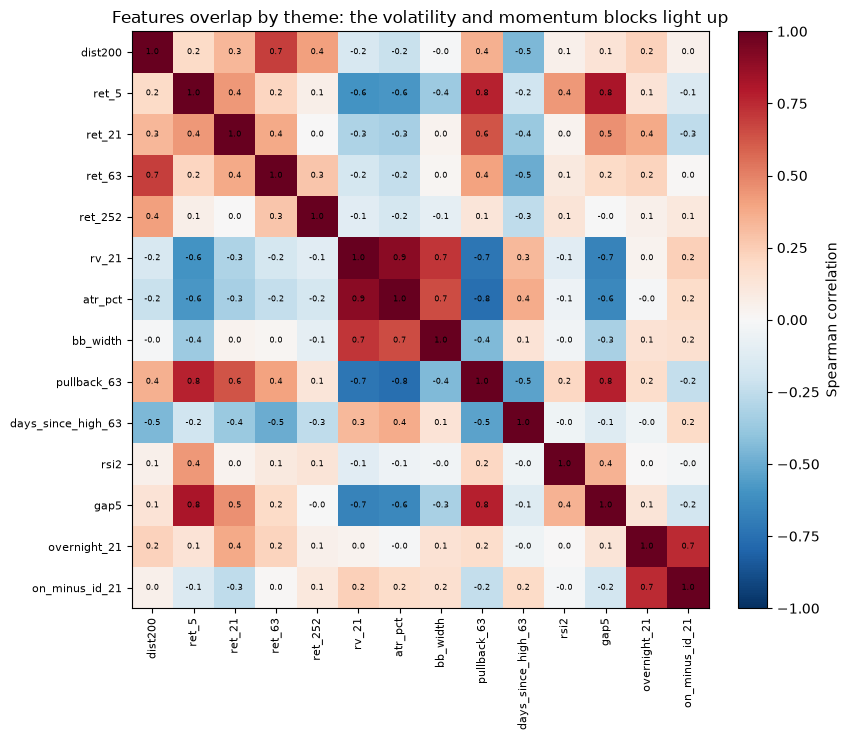

In [3]:
from scipy.stats import spearmanr

corr = pd.DataFrame(spearmanr(X).correlation, index=X.columns, columns=X.columns)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center",
                fontsize=6, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
ax.set_title("Features overlap by theme: the volatility and momentum blocks light up")
plt.tight_layout()
plt.show()

The volatility trio (`rv_21`, `atr_pct`, `bb_width`) is strongly correlated (around
0.7 to 0.9): they really are one signal wearing three hats. The momentum and pullback
features overlap too. This is not a bug, but it **breaks naive feature importance**.
When two features carry the same information, a tree splits on whichever it happens to
grab first, and the credit gets divided between them, so each looks half as important as
the idea really is (the **substitution effect**, Lopez de Prado, Ch. 8). The honest fix
is to read importance by **cluster**, not by individual column. Clustering the features
shows the groups explicitly.

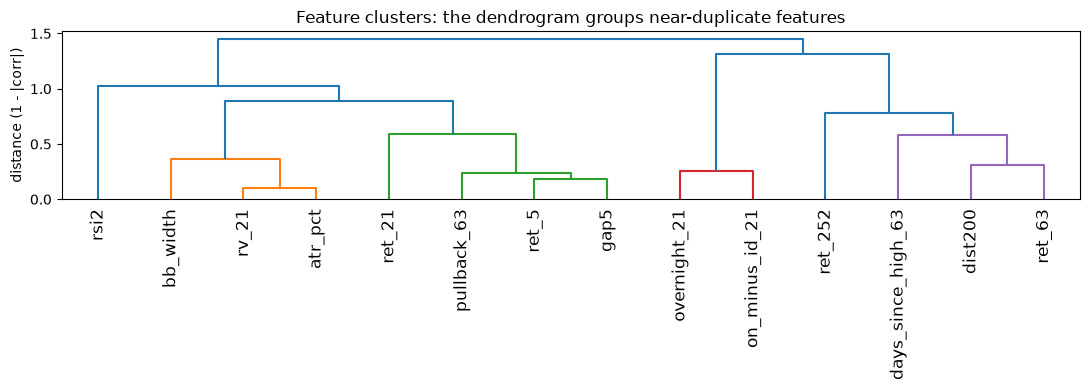

In [4]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Distance = 1 - |correlation|: features that move together sit close together.
dist = 1 - corr.abs()
link = hierarchy.ward(squareform(dist.values, checks=False))

fig, ax = plt.subplots(figsize=(11, 4))
hierarchy.dendrogram(link, labels=list(X.columns), leaf_rotation=90, ax=ax,
                     color_threshold=0.7)
ax.set_title("Feature clusters: the dendrogram groups near-duplicate features")
ax.set_ylabel("distance (1 - |corr|)")
plt.tight_layout()
plt.show()

## Do the features actually help? An honest importance preview

Now the real question. We measure importance the trustworthy way: **permutation
importance, out of sample**. Fit the model on the past, then on the held-out future
**shuffle one feature's column** and see how much the score drops. If scrambling a
feature barely hurts, the model was not really using it. We do this on the course's
**purged walk-forward** splits (Section 2), weight each trade by its Section 4 sample
weight, and average over folds and 8 random seeds so no single split or seed can fool us.

Two warnings to fix in your mind **before** reading the chart, because they decide how
much to trust it:

1. **165 trades is tiny.** Importances on a few hundred samples are unstable; the error
   bars will be large. Read the *clusters*, not the exact ranking.
2. This is a **preview, not a verdict**. Its job is to form hypotheses for Section 6, not
   to crown a winning feature.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

Xv, yv, wv = X.to_numpy(), y.to_numpy(), w.to_numpy()
cols = list(X.columns)
# Date-aware purge: each dip's label spans up to 5 trading days, so we drop any training
# dip whose label window reaches the next test block, not a fixed row count (Section 2).
folds = ev.purged_walk_forward(len(X), n_splits=5, label_horizon=1,
                               event_times=X.index, event_t1=labels["t1"].reindex(X.index))

# AUC = how well the model RANKS winners above losers out of sample. 0.5 is a coin flip.
drops = {c: [] for c in cols}
aucs = []
for tr, te in folds:
    if len(np.unique(yv[te])) < 2:           # need both classes in the test block to score
        continue
    for seed in range(8):
        m = RandomForestClassifier(n_estimators=300, max_features=1,
                                   min_samples_leaf=5, random_state=seed)
        m.fit(Xv[tr], yv[tr], sample_weight=wv[tr])
        base = roc_auc_score(yv[te], m.predict_proba(Xv[te])[:, 1])
        aucs.append(base)
        for j, c in enumerate(cols):
            rng = np.random.default_rng(1000 * seed + j)
            Xp = Xv[te].copy(); Xp[:, j] = rng.permutation(Xp[:, j])
            drops[c].append(base - roc_auc_score(yv[te], m.predict_proba(Xp)[:, 1]))

imp = pd.DataFrame({"mean": {c: np.mean(v) for c, v in drops.items()},
                    "std":  {c: np.std(v) for c, v in drops.items()}})
imp["group"] = [ft.FEATURE_GROUPS[c] for c in imp.index]
imp = imp.sort_values("mean")
print(f"out-of-sample AUC across folds and seeds: {np.mean(aucs):.3f}   (0.50 = a coin flip)")

out-of-sample AUC across folds and seeds: 0.467   (0.50 = a coin flip)


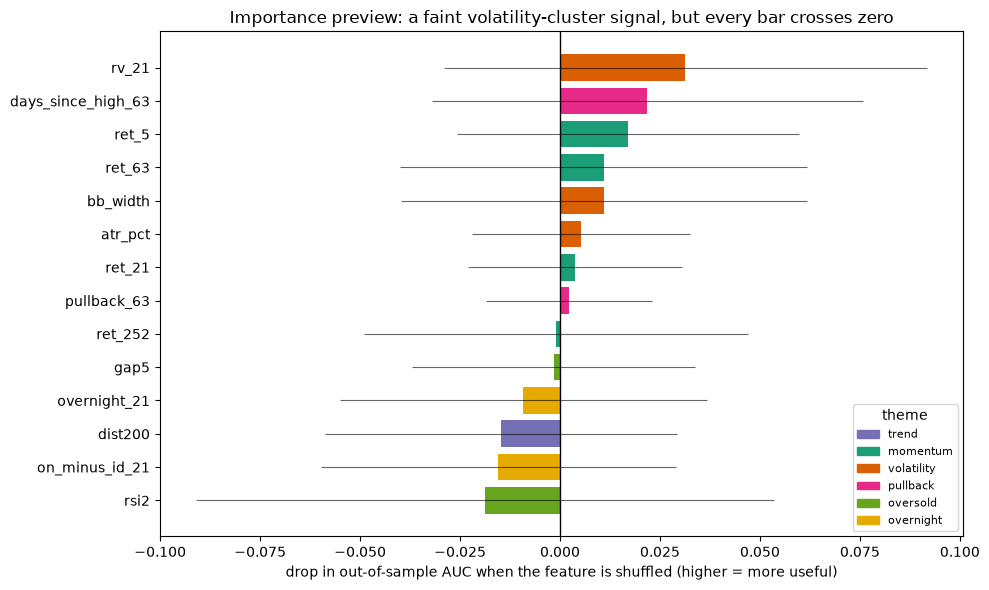

In [6]:
palette = {"trend": "#7570b3", "momentum": "#1b9e77", "volatility": "#d95f02",
           "pullback": "#e7298a", "oversold": "#66a61e", "overnight": "#e6ab02"}
colors = [palette[g] for g in imp["group"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp.index, imp["mean"], xerr=imp["std"], color=colors,
        error_kw={"elinewidth": 0.8, "alpha": 0.6})
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("drop in out-of-sample AUC when the feature is shuffled (higher = more useful)")
ax.set_title("Importance preview: a faint volatility-cluster signal, but every bar crosses zero")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), fontsize=8, loc="lower right", title="theme")
plt.tight_layout()
plt.show()

## Read it honestly

Two things jump out, and both are sobering:

- **The out-of-sample AUC is essentially a coin flip** (around 0.5, and if anything a
  hair below). On these 165 trades, the model cannot reliably rank the winning dips above
  the losing ones. The features, as a set, do not yet show a clear edge out of sample.
- **Every error bar comfortably crosses zero.** No single feature is reliably important.
  The volatility cluster edges out the rest, which would fit the theory that mean
  reversion pays most in stressed, high-volatility regimes (Nagel, 2012), but on this
  little data we **cannot confirm it**. Swap the validation scheme and the ranking
  reshuffles; that instability is the honest signature of a small sample.

This is not a failure, it is the *point* of doing it honestly. A flashy in-sample
importance chart would have happily crowned a "best feature." The out-of-sample,
weighted, multi-seed version tells the truth: there *may* be a faint volatility-regime
signal here, and that is a **hypothesis to test**, not a result to trust.

## The honest verdict, and what's next

The training set is now complete. Each of the ~165 dips carries:

- **`X`**: fourteen no-look-ahead features across six themes (trend, momentum,
  volatility, pullback, oversold, overnight);
- **`y`**: the triple-barrier meta-label from Section 4 (take / skip);
- **`w`**: the overlap-aware sample weight.

And we go in clear-eyed: out of sample, the features barely move the needle, and the only
faint signal (volatility regime) is well within the noise. Section 6 will give it the
best honest shot, a **CatBoost** meta-model trained on `X`, `y`, and `w`, validated with
purged walk-forward, and judged net of costs against both the raw 64%-win rule and
buy-and-hold. The question it must answer is the one this preview leaves wide open: can
filtering the dips turn "competitive" into a real edge, or does the signal simply
dissolve under honest validation?